<a href="https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/extras/Womersley_Flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LEARNING OBJECTIVE

This notebook illustrates Womersley's classic complex-variables solution for time-periodic unidirectional flow in a tube and in a slot. The flow rate and wall shear stress are computed using symbolic manipulations and plotted as functions of the dimensionless Womersley number.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [22]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

from matplotlib import animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25,
          'animation.embed_limit': 2**128}
plt.rcParams.update(params)
%matplotlib inline

import numpy as np
import scipy.special as sps

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org) &amp; Shrihari D. Pande, Purdue University.

# Womersley flow in a cylindrical pipe


## The axial flow profile

The velocity profile for post-transient unidirectional flow driven by an oscillatory pressure gradient, $-dp/dz=\Re\{G e^{\mathrm{i}\omega t}\}$, is:
$$
  v
_z(r,t) = \Re\left\{\frac{G a^2}{\mu} \frac{1}{\mathrm{i} α^2}\left[1-\frac{J_0(\mathrm{i}^{3/2}\alpha\space r/a)}{J_0(\mathrm{i}^{3/2}\alpha)}\right]e^{\mathrm{i}\omega t}\right\},
$$
where $\alpha=a \sqrt{\frac{\rho \omega}{\mu}}$ is the _Womersley number_ and $G = \Delta p/\ell$ is the equivalent steady gradient.

To make the profile dimensionless, we use the following variables:
$$
  R=\frac{r}{a},\quad Z=\frac{z}{\ell},\quad T=\frac{\omega t}{2 \pi},\quad V_Z=\frac{v_z}{\mathcal{V}_z},\quad \mathcal{V}_z=\frac{a^2 \Delta p}{\mu \ell}
$$
to obtain
$$
  V_Z(R,T)=\Re\left\{\frac{1}{\mathrm{i} α^2}\left[1-\frac{J_0(\mathrm{i}^{3/2}\alpha\space R)}{J_0(\mathrm{i}^{3/2}\alpha)}\right]e^{\mathrm{i} 2\pi T}\right\}.
$$


In [23]:
α, R, T = sp.symbols('α R T', real=True)
F = 1/(sp.I * α**2) * ( 1 - sp.besselj(0,sp.I**sp.Rational(3,2)*α*R) \
                            / sp.besselj(0,sp.I**sp.Rational(3,2)*α) )

In [24]:
Womersley = sp.lambdify([R,α,T], sp.re(F*sp.exp(sp.I*sp.pi*T*2)), 'scipy')

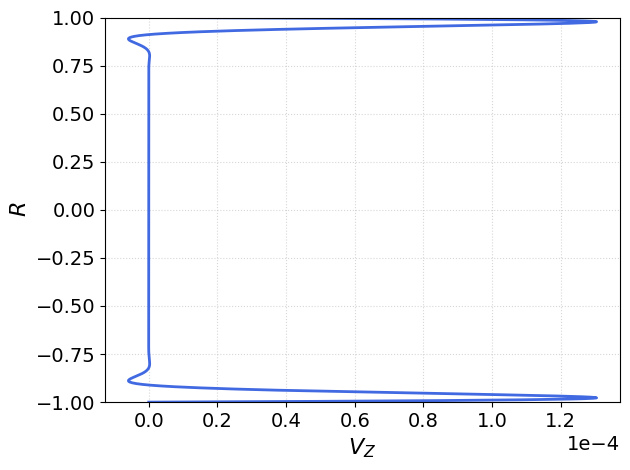

In [25]:
my_alpha = 50

my_R = np.linspace(-1,1,1000,endpoint=True)
V_z = Womersley(my_R,my_alpha,0)

fig, ax = plt.subplots(tight_layout=True)
#ax.set_ylim(0.9,1.1)
ax.set_ylabel('$R$')
ax.set_xlabel('$V_Z$')

ax.set_ylim(-1,1)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-3, 3)) 

ax.grid(alpha=0.5, linestyle='dotted')

ax.plot(V_z, my_R, color='royalblue', linewidth=2);

## The wall shear stress

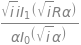

In [26]:
# the amplitude of the shear stress oscillations
Fp = F.diff(R)
Fp

In [27]:
sstress = sp.lambdify([R,α,T], Fp*sp.exp(sp.I*sp.pi*T*2), 'scipy')

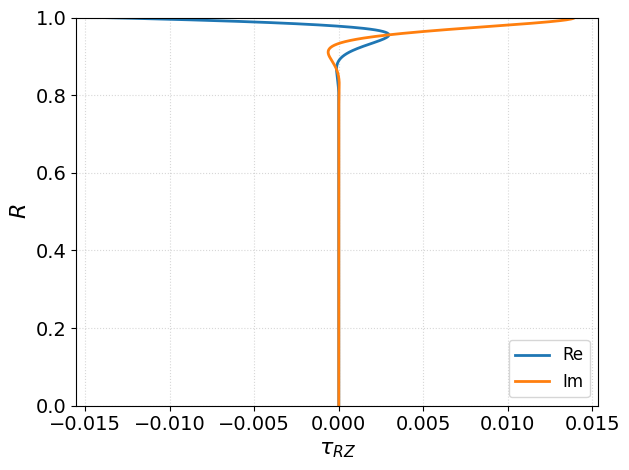

In [28]:
my_R = np.linspace(0,1,1000,endpoint=True)
ssa = sstress(my_R,my_alpha,0)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel('$R$')
ax.set_xlabel(r'$\tau_{RZ}$')

ax.plot(ssa.real, my_R, linewidth=2, label='Re')
ax.plot(ssa.imag, my_R, linewidth=2, label='Im')

ax.set_ylim(0,1)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-3, 3)) 

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend(loc='lower right');

In [29]:
wss = sp.lambdify(α, Fp.subs(R,1), 'scipy')

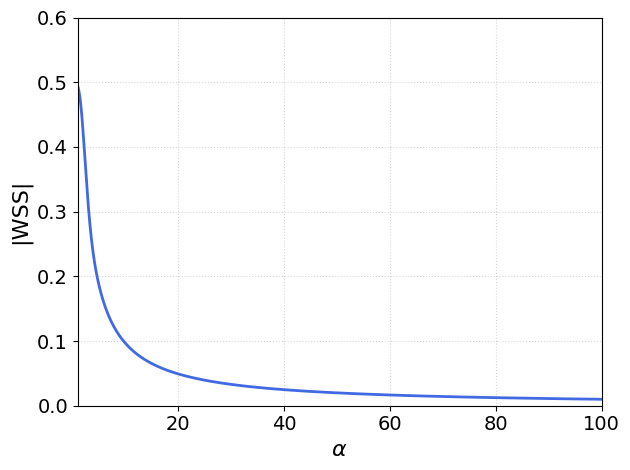

In [30]:
my_αs = np.linspace(1,100,1000)

fig, ax = plt.subplots(tight_layout=True)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('|WSS|')

ax.set_xlim(my_αs.min(), my_αs.max())
ax.set_ylim(0,0.6)

ax.grid(alpha=0.5, linestyle='dotted')

ax.plot(my_αs, abs(wss(my_αs)), color='royalblue', linewidth=2);

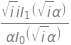

In [31]:
Fp.subs(R,1)

In [32]:
sp.limit(Fp.subs(R,1),α,0)

In [33]:
sp.limit(Fp.subs(R,1),α,sp.oo)

## The flow rate

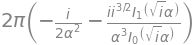

In [34]:
# the amplitude of the shear stress oscillations
Q = 2*sp.pi*sp.integrate(F*R,(R,0,1),conds='none').simplify()
Q

In [35]:
flowrate = sp.lambdify([α,T], Q*sp.exp(sp.I*sp.pi*T*2), 'scipy')

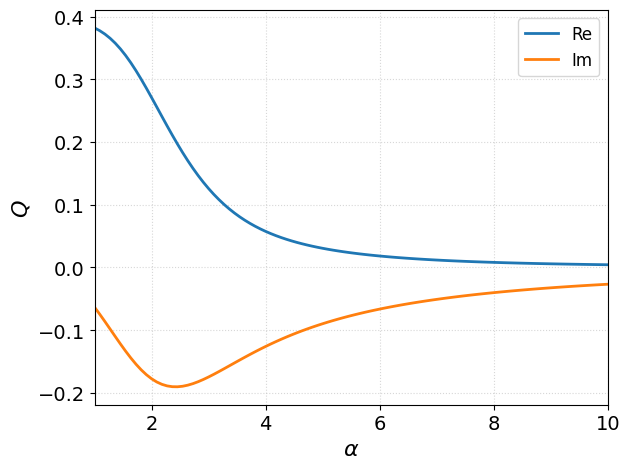

In [36]:
my_αs = np.linspace(1,10,100)

fig, ax = plt.subplots(tight_layout=True)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('$Q$')

ax.plot(my_αs, flowrate(my_αs,0).real, linewidth=2, label='Re')
ax.plot(my_αs, flowrate(my_αs,0).imag, linewidth=2, label='Im')

ax.set_xlim(my_αs.min(), my_αs.max())
#ax.set_ylim()

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

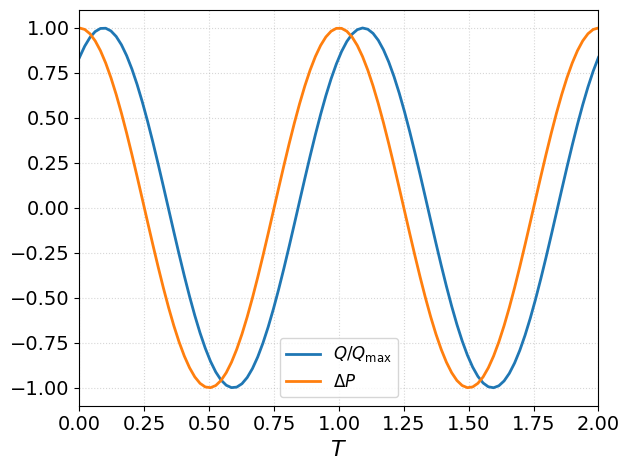

In [37]:
my_alpha = 2

my_Ts = np.linspace(0,2,100)

fig, ax = plt.subplots(tight_layout=True)
ax.set_xlabel(r'$T$')

q_plot = flowrate(my_alpha,my_Ts).real
q_plot = q_plot/q_plot.max()
dp_plot = (np.exp(1j*np.pi*my_Ts*2)).real

ax.plot(my_Ts, q_plot, linewidth=2, label='$Q/Q_\mathrm{max}$')
ax.plot(my_Ts, dp_plot, linewidth=2, label=r'$\Delta P$')

ax.set_xlim(my_Ts.min(), my_Ts.max())
#ax.set_ylim()

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

## Interactive plot

In [38]:
def plot_func(α,T):
  R = np.linspace(-1,1)
  V_z = Womersley(R,α,T)

  #plt.figure(2)
  fig, ax = plt.subplots(tight_layout=True)
  ax.set_ylabel('$R$')
  ax.set_ylim(-1,1)
  ax.set_xlabel('$V_Z$')
  #ax.set_xlim(min(V_z)-0.1,max(V_z)+0.1)
  ax.set_xlim(-0.5,0.5)

  ax.xaxis.set_major_locator(plt.MaxNLocator(4))
  ax.yaxis.set_major_locator(plt.MaxNLocator(4))

  # skip every other data point to reduce number of arrows
  # plot arrows emanating only from the reference line, x-coord = 0
  ax.quiver(0*R[::2], R[::2],
            V_z[::2], 0*V_z[::2],
            scale=1., scale_units='xy', color='skyblue', zorder=2)
  ax.plot(V_z, R, color='royalblue', linewidth=4, label=r'$\alpha='+str(α)+'$')
  ax.legend()

  ax.grid(alpha=0.5, linestyle='dotted')

  plt.show()

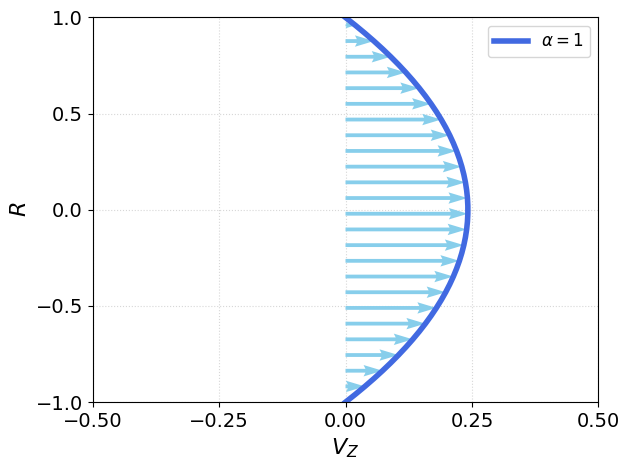

In [39]:
plot_func(1,0)

In [40]:
interact(plot_func, α = widgets.FloatSlider(value=1, min=0.1, max=20, step=0.1),
                    T = widgets.FloatSlider(min=0, max=2, step=0.1) );

interactive(children=(FloatSlider(value=1.0, description='α', max=20.0, min=0.1), FloatSlider(value=0.0, descr…

## Animation

We strat by making a thumbnail picture/initial plot (also useful when including into a $\LaTeX$ presentation).

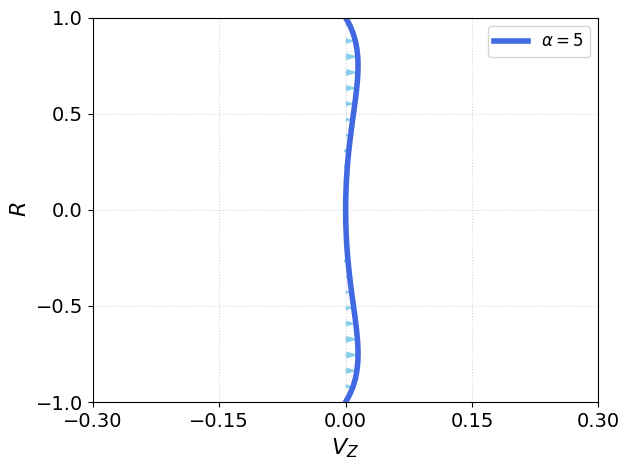

In [41]:
α = 5
R = np.linspace(-1,1)
V_z = Womersley(R,α,0)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel('$R$')
ax.set_ylim(-1,1)
ax.set_xlabel('$V_Z$')
#ax.set_xlim(min(V_z)-0.1,max(V_z)+0.1)
ax.set_xlim(-0.3,0.3)

ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.yaxis.set_major_locator(plt.MaxNLocator(4))

# skip every other data point to reduce number of arrows
# plot arrows emanating only from the reference line, x-coord = 0
quiv = ax.quiver(0*R[::2], R[::2],
                 V_z[::2], 0*V_z[::2],
                 scale=1., scale_units='xy', color='skyblue', zorder=2)
line, = ax.plot(V_z, R, color='royalblue', linewidth=4, label=r'$\alpha='+str(α)+'$')

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

In [42]:
# if you want to save the thumbnail to a file
#fig.savefig("Wo_0.5_thumb.pdf", bbox_inches='tight')

Then, we animate it.

In [43]:
def animate(i):
  V_z = Womersley(R,α,i/100)

  # update the plot data
  quiv.set_UVC(V_z[::2], 0*V_z[::2])
  line.set_xdata(V_z)

  return line, quiv,

ani = animation.FuncAnimation(fig, animate,
                              interval=20, blit=True, save_count=1000)

In [ ]:
# Note: below is the part which makes it work on Colab
rc('animation', html='jshtml')
ani

In [45]:
# To save the animation, use e.g.
#ani.save("Wo_5_movie.mp4")

# or
#writer = animation.FFMpegWriter(fps=15, metadata=dict(artist='Me'), bitrate=1800)
#ani.save("movie.mp4", writer=writer)

# Womersley flow in a 2D rectangual channel (slot)

## The axial flow profile

The dimensionless velocity profile is now
$$
  V_Z(Y,T) = \Re\left\{\frac{1}{\mathrm{i} α^2}\left[1-\frac{\cos\big(\mathrm{i}^{3/2}\alpha (1-2Y)/2\big)}{\cos\big(\mathrm{i}^{3/2}\alpha/2\big)}\right]e^{\mathrm{i} 2\pi T}\right\}.
$$


In [46]:
α, Y, T = sp.symbols('α Y T', real=True)
F2D = 1/(sp.I * α**2) * ( 1 - sp.cos(sp.I**sp.Rational(3,2)*α*(1-2*Y)/2) \
                              / sp.cos(sp.I**sp.Rational(3,2)*α/2) )

In [47]:
Womersley2D = sp.lambdify([Y,α,T], sp.re(F2D*sp.exp(sp.I*sp.pi*T*2)), 'scipy')

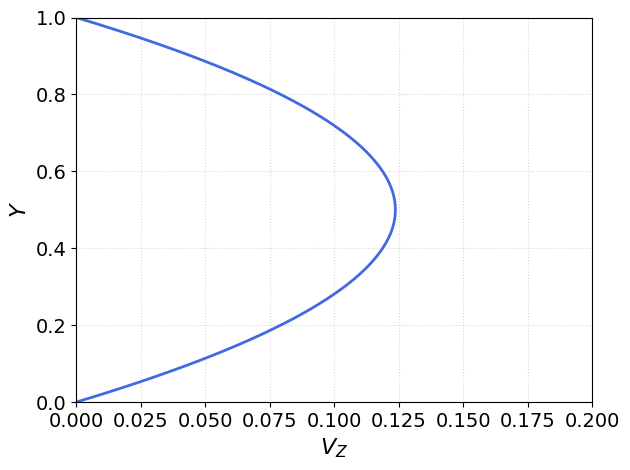

In [48]:
my_alpha = 1

my_Y = np.linspace(0,1,1000,endpoint=True)
V_z = Womersley2D(my_Y,my_alpha,0)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel('$Y$')
ax.set_xlabel('$V_Z$')

ax.set_xlim(0,0.2)
ax.set_ylim(0,1)

ax.grid(alpha=0.5, linestyle='dotted')
ax.ticklabel_format(axis='x', style='sci', scilimits=(-3, 3)) 

ax.plot(V_z, my_Y, color='royalblue', linewidth=2);

## The wall shear stress

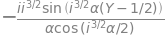

In [49]:
# the amplitude of the shear stress oscillations
Fp2D = F2D.diff(Y)
Fp2D.simplify()

In [50]:
sstress2D = sp.lambdify([Y,α,T], Fp2D*sp.exp(sp.I*sp.pi*T*2), 'scipy')

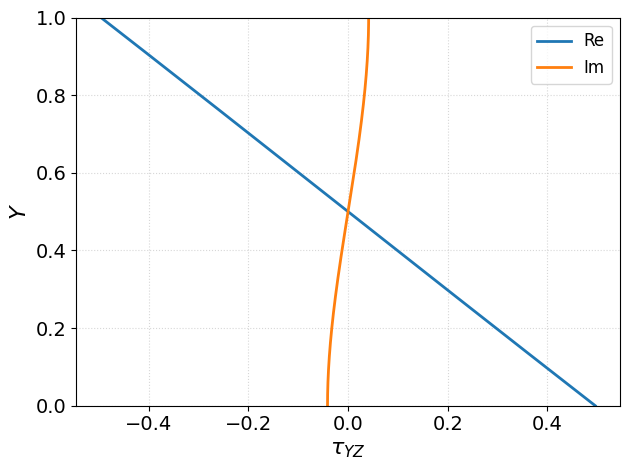

In [51]:
my_Y = np.linspace(0,1,1000,endpoint=True)
ssa2D = sstress2D(my_Y,my_alpha,0)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel('$Y$')
ax.set_xlabel(r'$\tau_{YZ}$')

ax.plot(ssa2D.real, my_Y, linewidth=2, label='Re')
ax.plot(ssa2D.imag, my_Y, linewidth=2, label='Im')

ax.set_ylim(0,1)
ax.ticklabel_format(axis='x', style='sci', scilimits=(-3, 3))

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

In [52]:
wss2D = sp.lambdify(α, Fp2D.subs(Y,1), 'scipy')

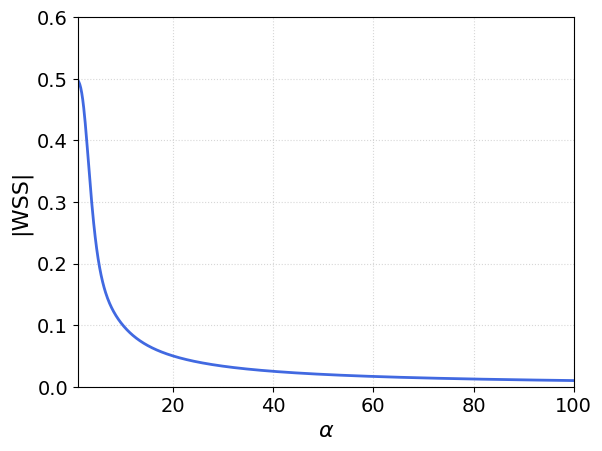

In [53]:
my_αs = np.linspace(1,100,1000)

ax = plt.gca()
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('|WSS|')

ax.plot(my_αs, abs(wss2D(my_αs)), color='royalblue', linewidth=2)

ax.set_xlim(my_αs.min(),my_αs.max())
ax.set_ylim(0,0.6)

ax.grid(alpha=0.5, linestyle='dotted');

In [54]:
Fp2D.subs(Y,1).simplify()

In [55]:
sp.limit(Fp2D.subs(Y,1),α,0)

In [56]:
#sp.limit(Fp2D.subs(Y,1),α,sp.oo,co)

## The flow rate

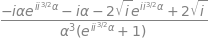

In [57]:
# the amplitude of the shear stress oscillations
# requires conds='none' because of the complex-valued integrand
Q2D = sp.integrate(F2D,(Y,0,1),conds='none').simplify()
Q2D

In [58]:
flowrate2D = sp.lambdify([α,T], Q2D*sp.exp(sp.I*sp.pi*T*2), 'scipy')

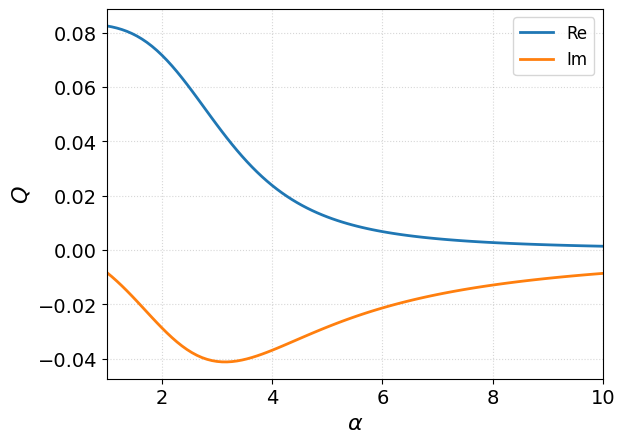

In [59]:
my_αs = np.linspace(1,10,100)

ax = plt.gca()
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('$Q$')

ax.plot(my_αs, flowrate2D(my_αs,0).real, linewidth=2, label='Re')
ax.plot(my_αs, flowrate2D(my_αs,0).imag, linewidth=2, label='Im')

ax.set_xlim(my_αs.min(), my_αs.max())
#ax.set_ylim()

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

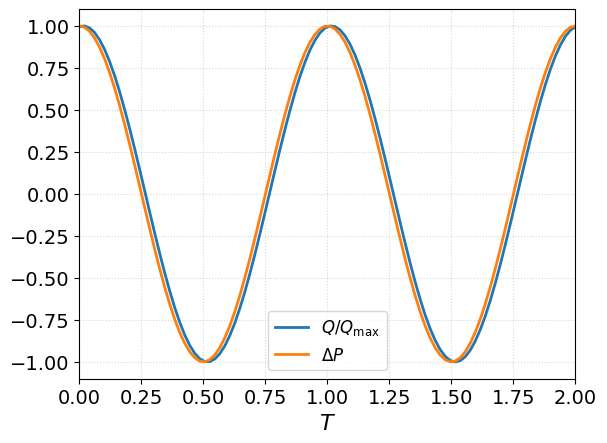

In [60]:
my_alpha = 1

my_Ts = np.linspace(0,2,100)

ax = plt.gca()
ax.set_xlabel(r'$T$')

q_plot = flowrate2D(my_alpha,my_Ts).real
q_plot = q_plot/q_plot.max()
dp_plot = (np.exp(1j*np.pi*my_Ts*2)).real

ax.plot(my_Ts, q_plot, linewidth=2, label='$Q/Q_\mathrm{max}$')
ax.plot(my_Ts, dp_plot, linewidth=2, label=r'$\Delta P$')

ax.set_xlim(my_Ts.min(), my_Ts.max())
#ax.set_ylim()

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend();

## Interactive plot

In [61]:
def plot_func(α,T):
  Y = np.linspace(0,1)
  V_z = Womersley2D(Y,α,T)

  #plt.figure(2)
  fig, ax = plt.subplots(tight_layout=True)
  ax.set_ylabel('$Y$')
  ax.set_ylim(0,1)
  ax.set_xlabel('$V_Z$')
  #ax.set_xlim(min(V_z)-0.1,max(V_z)+0.1)
  ax.set_xlim(-0.15,0.15)

  ax.xaxis.set_major_locator(plt.MaxNLocator(4))
  ax.yaxis.set_major_locator(plt.MaxNLocator(4))

  # skip every other data point to reduce number of arrows
  # plot arrows emanating only from the reference line, x-coord = 0
  ax.quiver(0*Y[::2], Y[::2],
            V_z[::2], 0*V_z[::2],
            scale=1., scale_units='xy', color='skyblue', zorder=2)
  ax.plot(V_z, Y, color='royalblue', linewidth=4, label=r'$\alpha='+str(α)+'$')
  ax.legend()

  ax.grid(alpha=0.5, linestyle='dotted')

  plt.show()

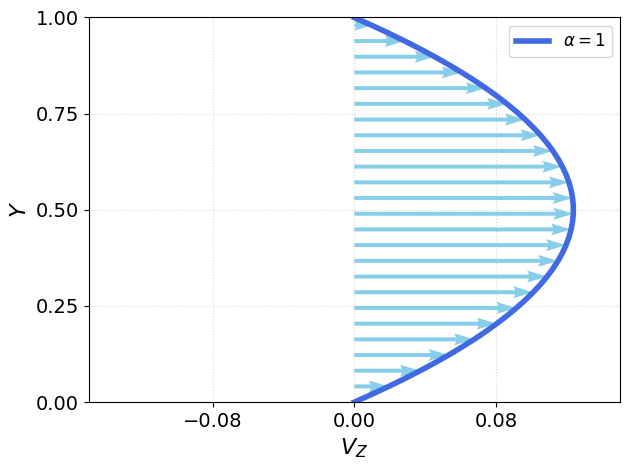

In [62]:
plot_func(1,0)

In [63]:
interact(plot_func, α = widgets.FloatSlider(value=1, min=0.1, max=20, step=0.1),
                    T = widgets.FloatSlider(min=0, max=2, step=0.1) );

interactive(children=(FloatSlider(value=1.0, description='α', max=20.0, min=0.1), FloatSlider(value=0.0, descr…